### Marketing campaign clustering

In [1]:
from typing import Optional

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

import scipy.cluster.hierarchy as sch
import matplotlib.cm as cm
from kneed import KneeLocator

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score, silhouette_samples, calinski_harabasz_score

In [2]:
# Zadanie 1
df = pd.read_csv("marketing_campaign.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   MaritalStatus        2240 non-null   str    
 3   Income               2216 non-null   float64
 4   KidsHome             2240 non-null   int64  
 5   TeensHome            2240 non-null   int64  
 6   CustomerFrom         2240 non-null   str    
 7   DaysLastPurchase     2240 non-null   int64  
 8   AmountWines          2240 non-null   int64  
 9   AmountFruits         2240 non-null   int64  
 10  AmountMeat           2240 non-null   int64  
 11  AmountFish           2240 non-null   int64  
 12  AmountSweets         2240 non-null   int64  
 13  AmountGoldProds      2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16 

In [3]:
df.describe()

,YearOfBirth,Income,KidsHome,TeensHome,DaysLastPurchase,AmountWines,AmountFruits,AmountMeat,AmountFish,AmountSweets,AmountGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


In [4]:
# Handle missing values from Income col (2216 out of 2240 records have income - 24 records missing)
df = df.drop(df[df["Income"].isnull()].index)

df = df.drop_duplicates(keep="first")

df.info() # Total 2015 records left in df after removing rows with null Income and duplicates

<class 'pandas.DataFrame'>
Index: 2015 entries, 0 to 2239
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   YearOfBirth          2015 non-null   int64  
 1   Education            2015 non-null   str    
 2   MaritalStatus        2015 non-null   str    
 3   Income               2015 non-null   float64
 4   KidsHome             2015 non-null   int64  
 5   TeensHome            2015 non-null   int64  
 6   CustomerFrom         2015 non-null   str    
 7   DaysLastPurchase     2015 non-null   int64  
 8   AmountWines          2015 non-null   int64  
 9   AmountFruits         2015 non-null   int64  
 10  AmountMeat           2015 non-null   int64  
 11  AmountFish           2015 non-null   int64  
 12  AmountSweets         2015 non-null   int64  
 13  AmountGoldProds      2015 non-null   int64  
 14  NumDealsPurchases    2015 non-null   int64  
 15  NumWebPurchases      2015 non-null   int64  
 16  NumC

In [5]:
# Convert CustomerFrom column from str date (DD-MM-YYYY) to number of days from provided date up untill today
def get_days_from_today(date_str: str):
    target_date = datetime.strptime(date_str, '%d-%m-%Y').date()
    today = datetime.now().date()
    
    delta = today - target_date
    return delta.days

df["CustomerFrom"] = df["CustomerFrom"].apply(get_days_from_today)

# Create Age column based on birth year
df["Age"] = datetime.now().year - df["YearOfBirth"]

In [6]:
# list all unique values from Education col
education_degrees = df["Education"].unique()
# based on this, ordered list for ordinal encoder class
education_ordered = [
    'Basic', 'Graduation', '2n Cycle', 'Master', 'PhD' 
]

ordinal_encoder = OrdinalEncoder(categories=[education_ordered])
encoded_education = ordinal_encoder.fit_transform(df[["Education"]])
df["Education"] = encoded_education

<Axes: xlabel='HasChild', ylabel='count'>

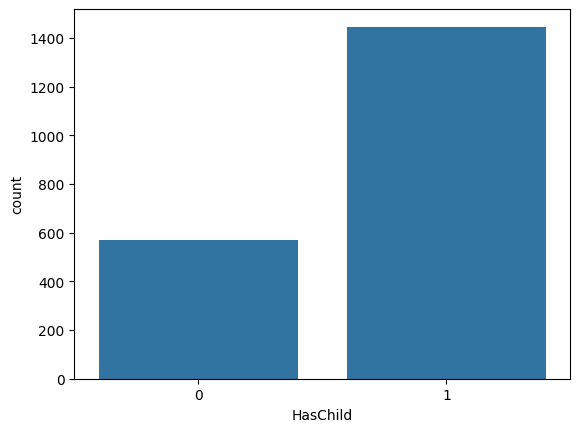

In [7]:
# family data preprocessing -> create new column that aggregates outcomes, if there is 1 or more children in family, input 1 (truthy value), 0 (falsy) otherwise
df["HasChild"] = (df["KidsHome"] + df["TeensHome"]).gt(0).astype(int)

# How many clients does have at least 1 child
sns.countplot(df, x="HasChild")

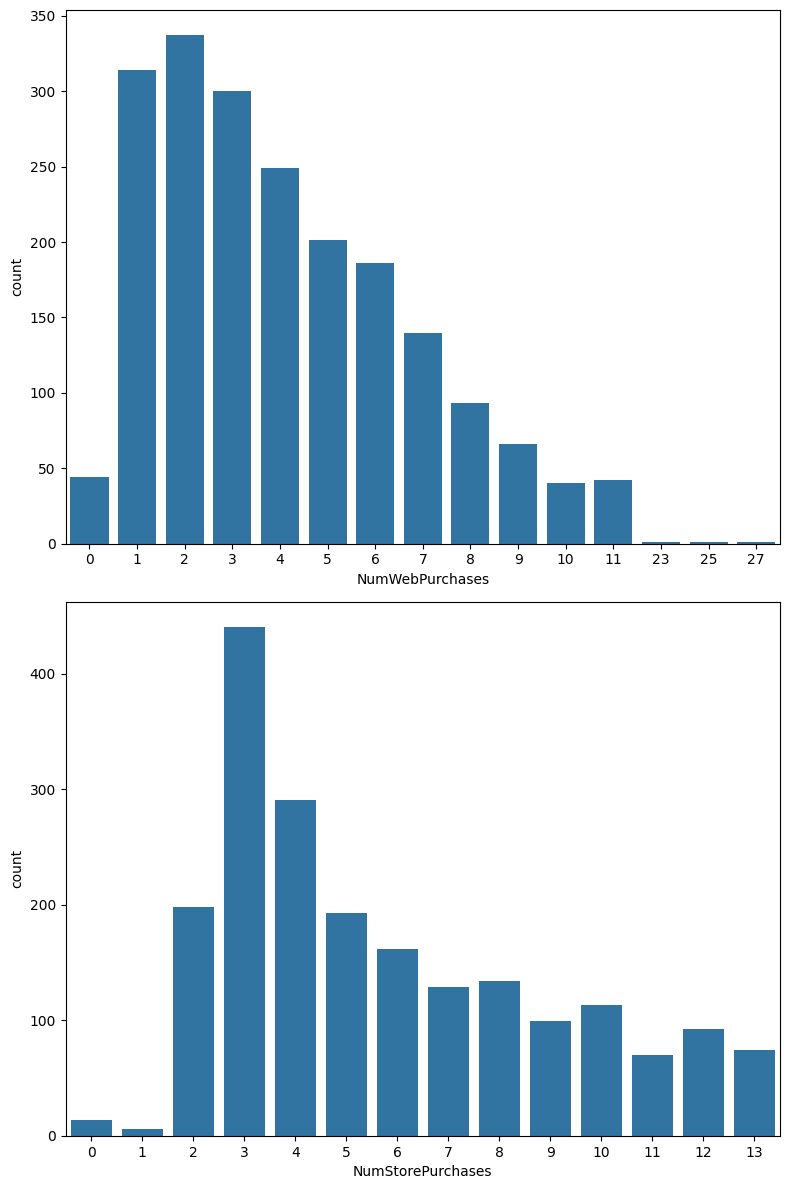

OnlineClient
0    1673
1     342
Name: count, dtype: int64

Online clients:   17.0%
In-store clients: 83.0%


In [8]:
# client preferences preprocessing -> describe client preferences as web / instore 
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

sns.countplot(data=df, x="NumWebPurchases", ax=axes[0])
sns.countplot(data=df, x="NumStorePurchases", ax=axes[1])

plt.tight_layout()
plt.show()

# if NumWebPurchases exceeds NumStorePurchase, categorize client as a client who preferes to shop online -> binary value 1 (online client type) & 0 (instore client type)
df["OnlineClient"] = (df["NumWebPurchases"] > df["NumStorePurchases"]).astype(int)

print(df["OnlineClient"].value_counts())
print(f"\nOnline clients:   {df['OnlineClient'].mean():.1%}")
print(f"In-store clients: {(1 - df['OnlineClient'].mean()):.1%}")

In [9]:
# During EDA two records had 'YOLO' as MartialStatus and two had 'Absurd' -> qualified for dropping from dataset
martial_statuses = df["MaritalStatus"].unique()

df = df.drop(df[df["MaritalStatus"] == "YOLO"].index)
df = df.drop(df[df["MaritalStatus"] == "Absurd"].index)

married_cnt = df['MaritalStatus'].value_counts().get('Married', 0)
together_cnt = df['MaritalStatus'].value_counts().get('Together', 0)

widows_cnt = df['MaritalStatus'].value_counts().get('Widow', 0)
divorced_cnt = df['MaritalStatus'].value_counts().get('Divorced', 0)

alone_cnt = df['MaritalStatus'].value_counts().get('Alone', 0)
single_cnt = df['MaritalStatus'].value_counts().get('Single', 0)

martial_statues_cnts = f"""
Married cnt: {married_cnt}
Together cnt: {together_cnt}
Divorced cnt: {divorced_cnt}
Widows cnt: {widows_cnt}
Alone cnt: {alone_cnt}
Single cnt: {single_cnt}
"""

# Based on very similar structure of martial statuses, it's convinient to apply binning for feature engineering  
# 3 separate groups, single, in-relationship, after-relationship (aggregated widows + divorced - tough situation after marriage break-up or losing someone)
print(martial_statues_cnts)

def replace_martial_status(status: str) -> str:
    match status:
        case "Married" | "Together":
            return "In-relationship"
        case "Alone" | "Single":
            return "Single"
        case "Widow" | "Divorced":
            return "Tough breakup"
        
df["MaritalStatus"] = df["MaritalStatus"].map(replace_martial_status)

# Use one hot encoding for MartialStatus bins
one_hot_encoder = OneHotEncoder(drop="first", sparse_output=False)
martial_status_1hot_encoded = one_hot_encoder.fit_transform(df[["MaritalStatus"]])
martial_status_1hot_encoded_df = pd.DataFrame(martial_status_1hot_encoded, columns=one_hot_encoder.get_feature_names_out())

df = df.drop(labels=["MaritalStatus"], axis=1)
df = df.reset_index(drop=True)
df = pd.concat([df, martial_status_1hot_encoded_df], axis=1)


Married cnt: 781
Together cnt: 510
Divorced cnt: 213
Widows cnt: 69
Alone cnt: 3
Single cnt: 436



<Axes: ylabel='Income'>

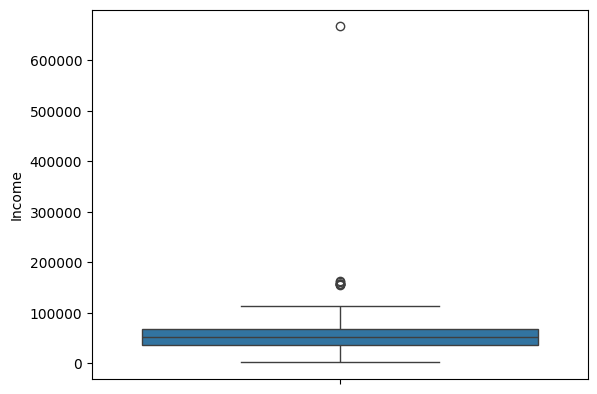

In [10]:
# Explore data to find outliers from each numeric col

sns.boxplot(df["Income"]) 

<Axes: ylabel='KidsHome'>

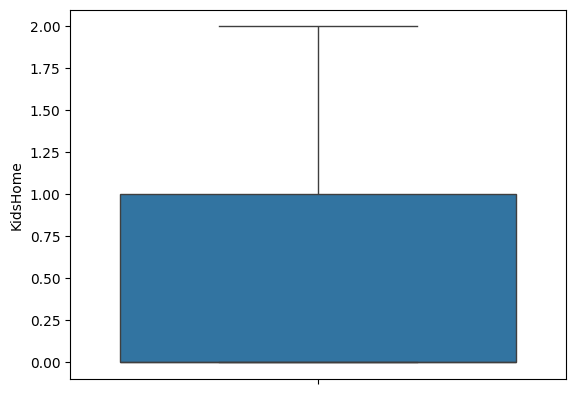

In [11]:
sns.boxplot(df["KidsHome"])

<Axes: ylabel='TeensHome'>

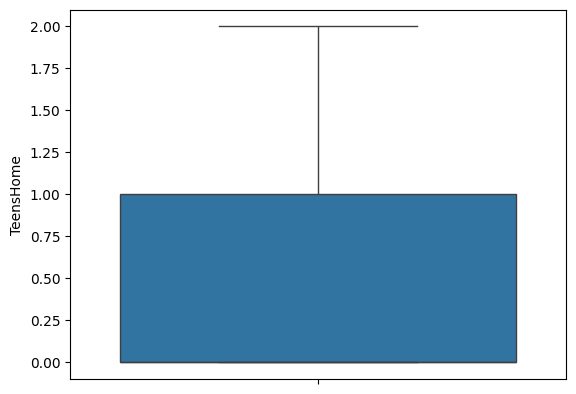

In [12]:
sns.boxplot(df["TeensHome"])

<Axes: ylabel='CustomerFrom'>

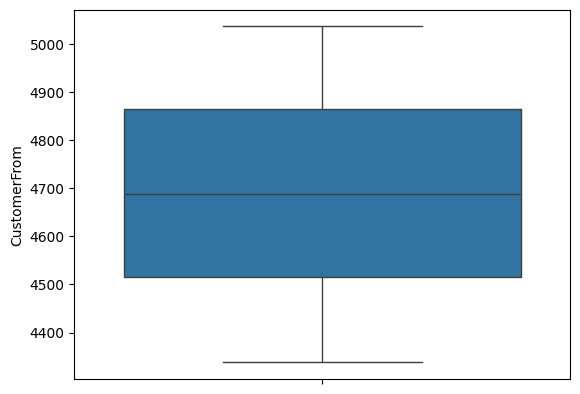

In [13]:
sns.boxplot(df["CustomerFrom"])

<Axes: ylabel='DaysLastPurchase'>

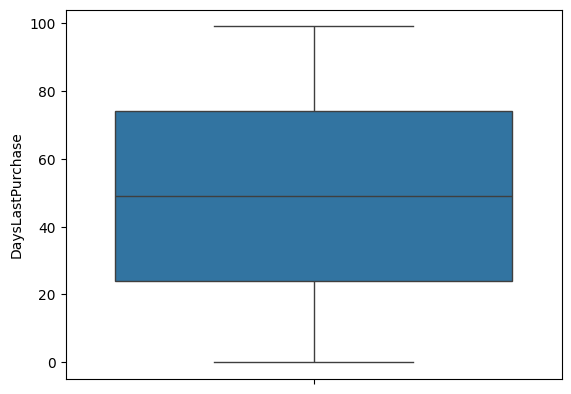

In [14]:
sns.boxplot(df["DaysLastPurchase"])

<Axes: ylabel='AmountWines'>

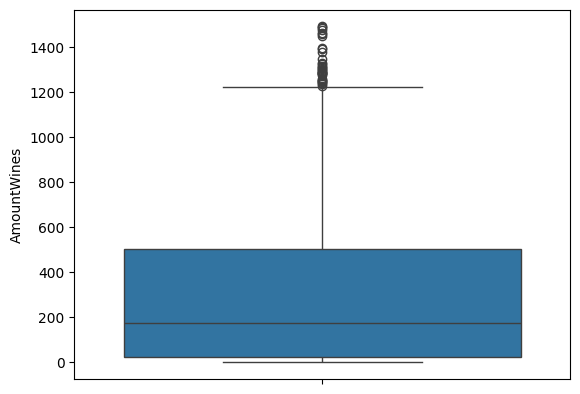

In [15]:
sns.boxplot(df["AmountWines"]) 

<Axes: ylabel='AmountFruits'>

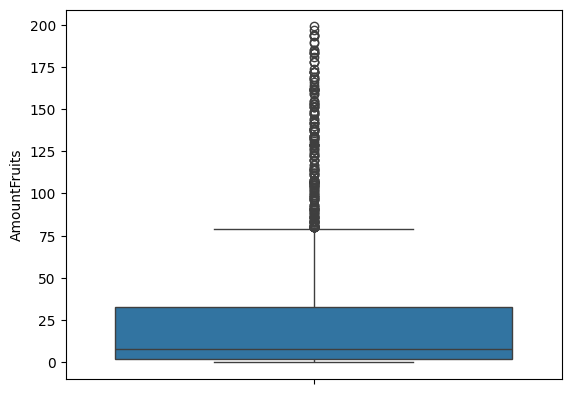

In [16]:
sns.boxplot(df["AmountFruits"]) 

<Axes: ylabel='AmountMeat'>

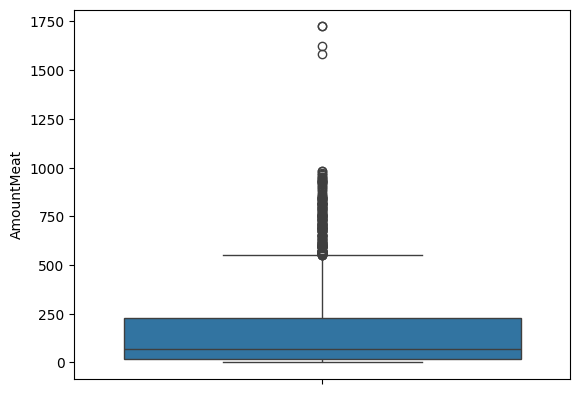

In [17]:
sns.boxplot(df["AmountMeat"]) 

<Axes: ylabel='AmountFish'>

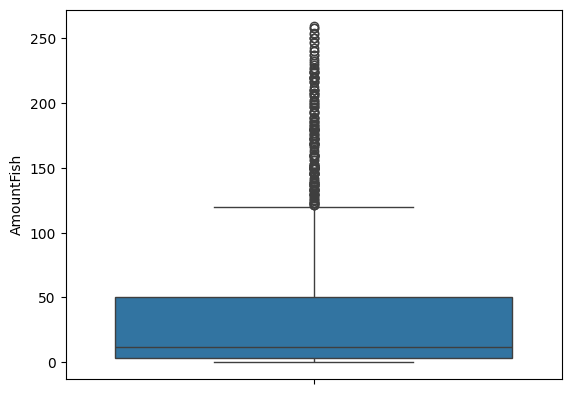

In [18]:
sns.boxplot(df["AmountFish"]) 

<Axes: ylabel='AmountSweets'>

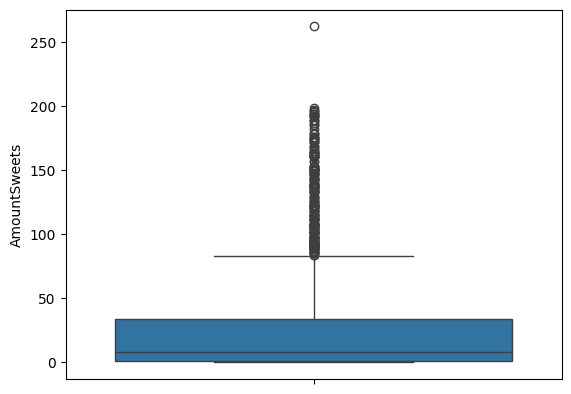

In [19]:
sns.boxplot(df["AmountSweets"]) 

<Axes: ylabel='AmountGoldProds'>

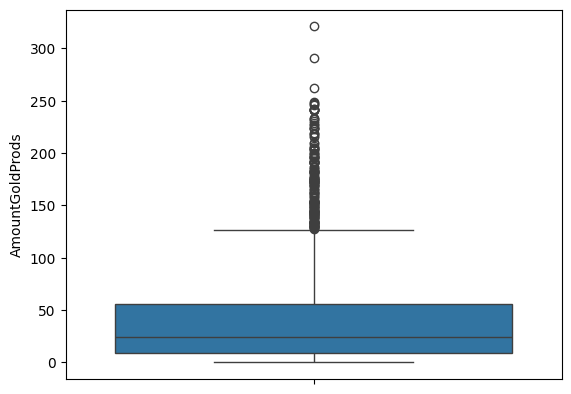

In [20]:
sns.boxplot(df["AmountGoldProds"]) 

<Axes: ylabel='NumDealsPurchases'>

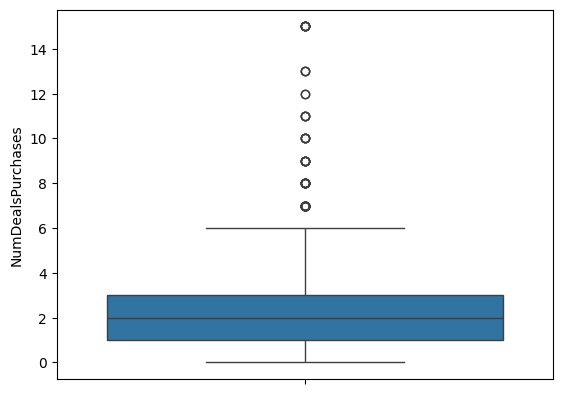

In [21]:
sns.boxplot(df["NumDealsPurchases"]) 

<Axes: ylabel='NumWebPurchases'>

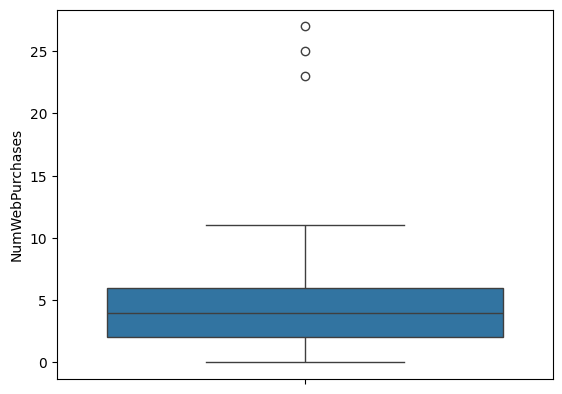

In [22]:
sns.boxplot(df["NumWebPurchases"]) 

<Axes: ylabel='NumCatalogPurchases'>

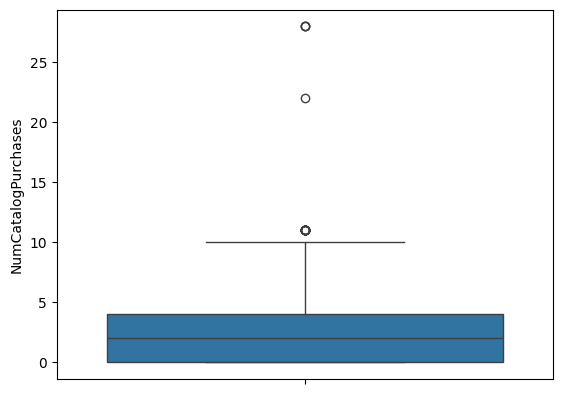

In [23]:
sns.boxplot(df["NumCatalogPurchases"]) 

<Axes: ylabel='NumStorePurchases'>

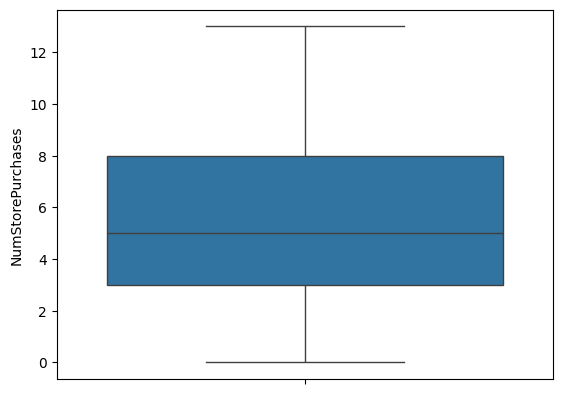

In [24]:
sns.boxplot(df["NumStorePurchases"])

<Axes: ylabel='NumWebVisitsMonth'>

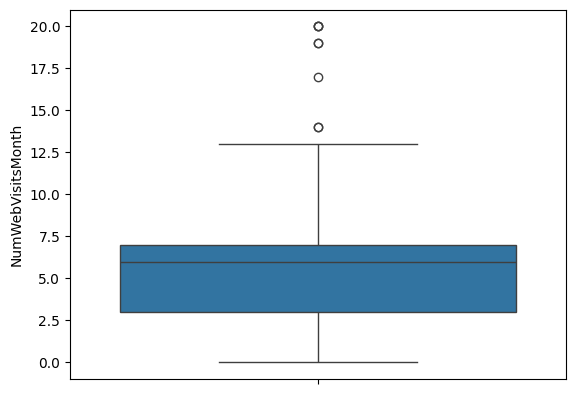

In [25]:
sns.boxplot(df["NumWebVisitsMonth"]) 

In [26]:
# Handle outliers by clipping 
cols_to_clip = ["Income", "AmountWines", "AmountFruits", "AmountMeat", "AmountFish", "AmountSweets", "AmountGoldProds", "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumWebVisitsMonth", "NumStorePurchases"]

stds = df[cols_to_clip].std(axis=0)
means = df[cols_to_clip].mean(axis=0)

df[cols_to_clip] = df[cols_to_clip].clip(
    lower=means - 3 * stds,
    upper=means + 3 * stds,
    axis=1
)

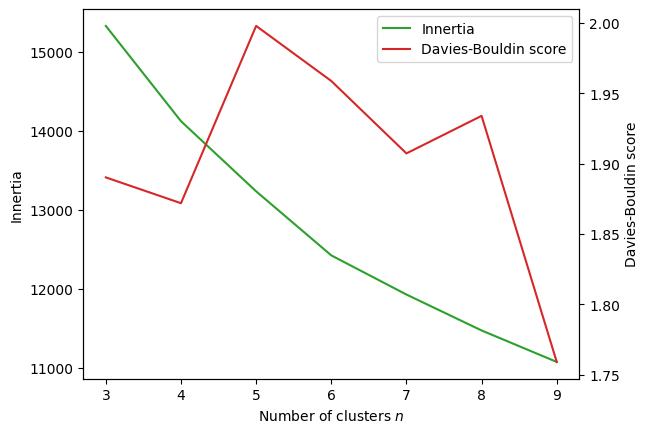

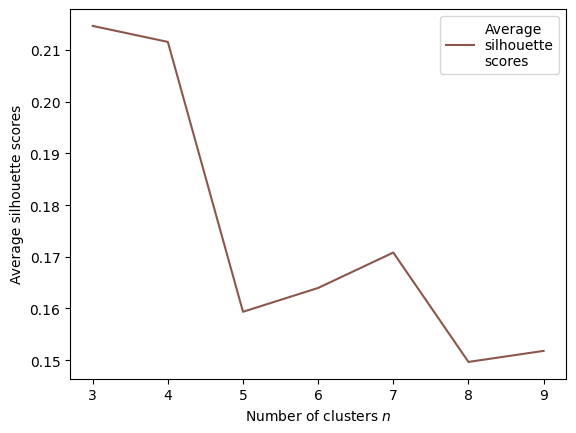

In [27]:
# Zadanie 2
# Starting with scaling selected features for first clustering try
scaler = StandardScaler()

# Chosen features for first clustering trial
X = df[[
    "Age", # Age of single person
    "Education", # Ordinal features based on education degree
    "Income", # Annual income
    "HasChild", # Wheter someone has 1+ kids, or no kids at all
    "OnlineClient", # Client prefferences Online / Instore
    "CustomerFrom",  # For how long is customer a client of the store
    "AmountWines", 
    "AmountFruits", 
    "AmountMeat", 
    "AmountFish", 
    "AmountSweets", 
    "AmountGoldProds", 
]].values

X_scaled = scaler.fit_transform(X)

def plot_cluster_search(X: np.ndarray) -> tuple[list[float], list[float], list[float]]:
    """
    
    """
    # Find number of cluster
    inertias, dbs, silhouette_scores = [], [], []

    for n in range(3, 10):
        k_means_test = KMeans(n_clusters=n, n_init=10)
        k_means_test.fit(X)
        inertias.append(k_means_test.inertia_)
        dbs.append(davies_bouldin_score(X, k_means_test.labels_))
        silhouette_scores.append(silhouette_score(X, k_means_test.labels_))

    _, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    l1 = ax1.plot(range(3, 10), inertias, color='C2', label="Innertia")
    l2 = ax2.plot(range(3, 10), dbs, color='C3', label='Davies-Bouldin score')
    ax1.set_xlabel("Number of clusters $n$")
    ax1.set_ylabel("Innertia")
    ax2.set_ylabel("Davies-Bouldin score")
    ax2.grid(False)
    ax1.legend(handles=[l1[0], l2[0]], loc='upper right')
    plt.show()

    plt.plot(range(3, 10), silhouette_scores, color='C5', label='Average\nsilhouette\nscores')
    plt.xlabel("Number of clusters $n$")
    plt.ylabel('Average silhouette scores')
    plt.legend(loc='upper right')
    plt.show()

    return inertias, dbs, silhouette_scores

inertias, dbs, silhouette_scores = plot_cluster_search(X=X_scaled)

WCV = 14124.424759505253


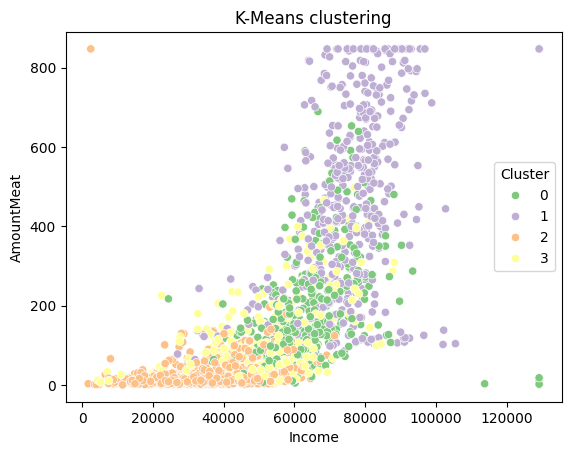

In [28]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
print(f'WCV = {kmeans.inertia_}')

sns.scatterplot(df, x='Income', y='AmountMeat', hue='Cluster', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountMeat')
plt.title('K-Means clustering')
plt.show()

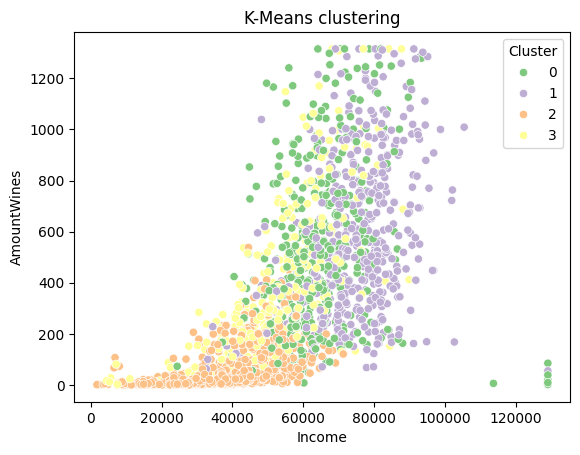

In [29]:
sns.scatterplot(df, x='Income', y='AmountWines', hue='Cluster', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountWines')
plt.title('K-Means clustering')
plt.show()

Note to AmountWines features: We can clearly see that cluster 1 and 3 are highest cash spenders in wine sector. From around 60k annual income wine spending habit clearly rises.

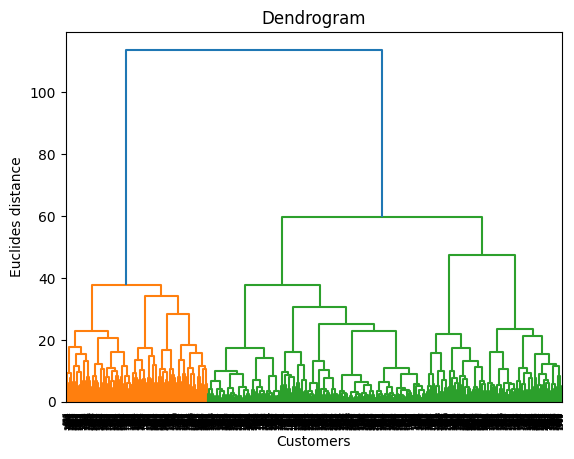

In [30]:
dendogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclides distance')
plt.show()

In [31]:
kl = KneeLocator(range(3, 10), inertias, curve="convex")
print(f'Knee locator based optimum cluster amount: {kl.elbow}')

Knee locator based optimum cluster amount: 9


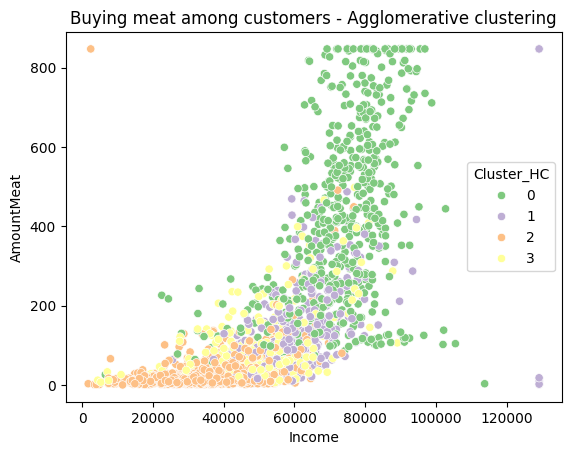

In [32]:

hc = AgglomerativeClustering(n_clusters=4)
df['Cluster_HC'] = hc.fit_predict(X_scaled)
sns.scatterplot(df, x='Income', y='AmountMeat', hue='Cluster_HC', palette='Accent')
plt.xlabel('Income')
plt.ylabel('AmountMeat')
plt.title('Buying meat among customers - Agglomerative clustering')
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_70994/3836551636.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=kmeans.labels_, y=df['AmountMeat'], palette='Accent')


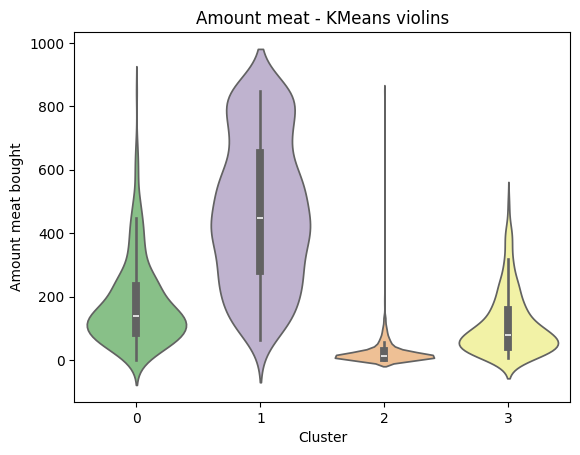

In [33]:
sns.violinplot(x=kmeans.labels_, y=df['AmountMeat'], palette='Accent')
plt.xlabel('Cluster')
plt.ylabel('Amount meat bought')
plt.title("Amount meat - KMeans violins")
plt.show()

/var/folders/8m/2bmbch8140x5z1y896yqv01r0000gn/T/ipykernel_70994/3689098935.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=hc.labels_, y=df['AmountMeat'], palette='Accent')


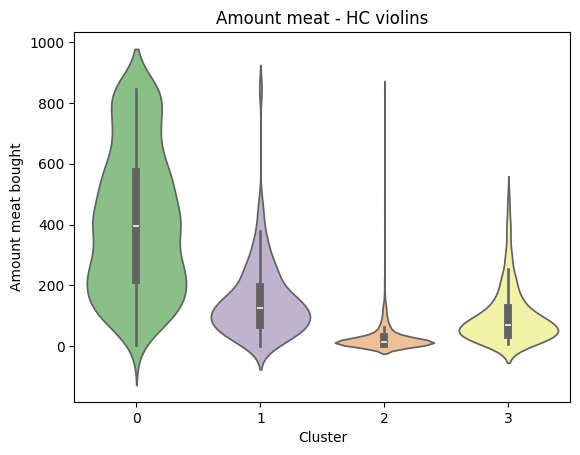

In [34]:
sns.violinplot(x=hc.labels_, y=df['AmountMeat'], palette='Accent')
plt.xlabel('Cluster')
plt.ylabel('Amount meat bought')
plt.title("Amount meat - HC violins")
plt.show()

In [35]:
def get_sillhouette_diagram(
        X: np.ndarray, 
        labels, 
        n_clusters: int, 
        show_scatter: bool,
        first_feature_idx: Optional[int] = None,  
        sec_feature_idx: Optional[int] = None
    ) -> None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    savg = silhouette_score(X, labels)
    ssv = silhouette_samples(X, labels)
    y_lower = 10

    for i in range(n_clusters):
        icsv = ssv[labels == i]
        icsv.sort()
        sci = icsv.shape[0]
        y_upper = y_lower + sci
        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, icsv, facecolor=color,
        edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * sci, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=savg, color="red", linestyle="--")
    ax1.set_title("Silhouette diagram")
    ax1.set_xlabel("Silhouette score")
    ax1.set_ylabel("Cluster label")
    ax1.set_yticks([])
    ax1.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    colors = cm.nipy_spectral(labels.astype(float) / n_clusters)
    if show_scatter:
        ax2.scatter(X[:, first_feature_idx], X[:, sec_feature_idx], marker=".", s=30, lw=0, alpha=0.7, c=colors,edgecolor="k")
    fig.tight_layout()

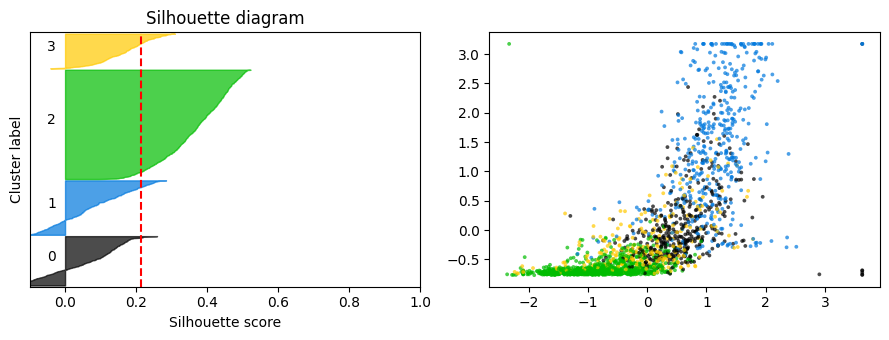

In [36]:
labels = kmeans.fit_predict(X_scaled)
get_sillhouette_diagram(
    X=X_scaled,
    labels=labels,
    n_clusters=4,
    show_scatter=True,
    first_feature_idx=2,
    sec_feature_idx=8
)

#### Summary of first try K-Means and AgglomerativeClustering

The first attempt seems to be noisy. I decided to not include every feature from dataframe in X variable, as K-Means is sensitive for dataseta dimensionality.

The optimal cluster amount appears to be 5 according to Davies-Bouldin and Silhouette scores. The Dendrogram chart displayed a distinction into three separate clusters, but i tried to go for four cluster choosing value between silheutte/DB score and dendogram result.

We can try to distinguish four groups:
1. Low income people, who buy fewer products due to the necessity of saving money and having less disposable income in general.

2 & 3. Two mid-level income groups, where spending habits can depend on individual behavior. One group represents the lower bound mid-tier, and the second naturally has slightly higher income and higher spending habits.

4. High income people, where we naturally observe the highest amounts of products purchased and the highest overall spending.

Using 4 clusters and looking at the silhouette diagram and violin plots, we can make initial assumptions that clusters labeled 0 and 2 can be somewhat targeted with business marketing strategies. What is good, is the fact that both algorithms - K-Means and Agglomerative clustering aggregates customers into similar looking clusters - naturally labeled differently but looking at violin plot of AmountMeat feature for hc and kmeans gives us similar plots.

The groupings are wider, and beyond the red average score line we observe a wide spread — meaning the points appear to be correctly assigned to their clusters, which can guide targeted commercial decisions.
The blue cluster has some negative scores, which suggests the model had difficulty correctly assigning some customers, and does not see clear boundaries for that cluster. This indicates we should consider better grouping methodologies, as the first attempt gives us some hints about customer segments but clearly shows significant room for model improvement.

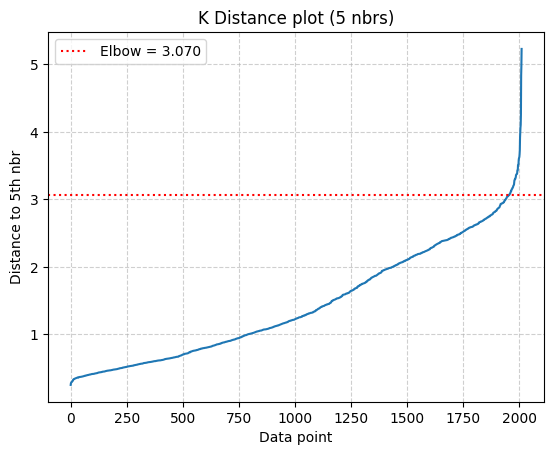

Suggested eps: 3.0695


In [37]:
# Zadanie 3
nn = NearestNeighbors(n_neighbors=5)  # 5 neighbors (index 0 = self, so 4 true neighbors + self)
nbrs = nn.fit(X_scaled)

distances, indices = nn.kneighbors(X_scaled)
distances = distances[:, 4]
distances = np.sort(distances)

kl = KneeLocator(
    range(len(distances)),
    distances,
    curve='convex',
    direction='increasing'
)

plt.figure()
plt.plot(distances)
plt.axhline(distances[kl.elbow], color='r', linestyle=':', label=f'Elbow = {distances[kl.elbow]:.3f}')
plt.title("K Distance plot (5 nbrs)")
plt.xlabel("Data point")
plt.ylabel("Distance to 5th nbr")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

print(f"Suggested eps: {distances[kl.elbow]:.4f}")

In [38]:
def find_db_scan_hp(X_scaled: np.ndarray, lower_bound: float, suggested_eps: float):
    min_samples = range(3, 13)
    eps = np.arange(lower_bound, suggested_eps, 0.01)
    silhsc = {}
    for ms in min_samples:
        silhsc[ms] = []
        for ep in eps:
            labels = DBSCAN(min_samples=ms, eps = ep).fit_predict(X_scaled)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters == 2:
                silhsc[ms].append((n_clusters, ep, silhouette_score(X_scaled, labels)))
        if silhsc[ms]:
            silhsc[ms] = sorted(silhsc[ms], key=lambda x: x[-1])[-1]
        else:
            silhsc[ms] = (None, None, None) 
    print(pd.DataFrame(silhsc).T.reset_index().rename(columns={'index': 'NumPts', 0: 'Num of clusters', 1: 'epsilon',2: 'Silhouette index'}))

In [39]:
find_db_scan_hp(X_scaled=X_scaled, lower_bound=2.0, suggested_eps=distances[kl.elbow])

   NumPts  Num of clusters  epsilon  Silhouette index
0       3              2.0     3.06          0.167506
1       4              2.0     3.06          0.166670
2       5              2.0     2.81          0.221123
3       6              2.0     2.86          0.217707
4       7              2.0     2.81          0.221525
5       8              2.0     2.95          0.216775
6       9              2.0     2.23          0.162427
7      10              2.0     2.23          0.163632
8      11              2.0     2.27          0.163961
9      12              2.0     2.23          0.165340


0.29459148846745636 3.113850008470719 11.646717347264872
Silhouette score: 0.29459148846745636
davies bouldin scores: 3.113850008470719
calinski hrabasz score: 11.646717347264872
Number of cluster:  1
Amount of points intepreted as noise: 20


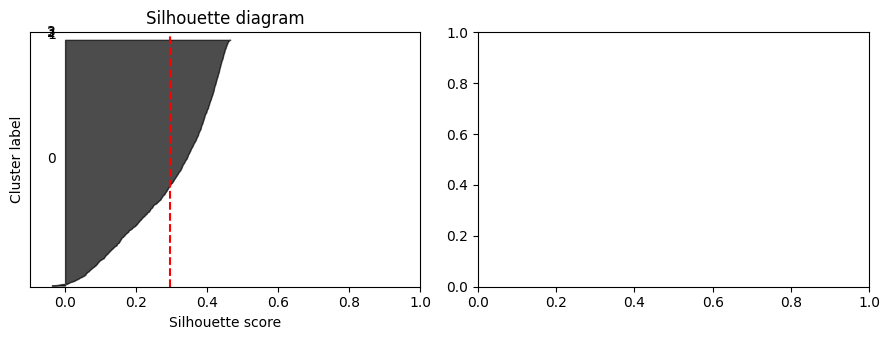

In [40]:
labels = DBSCAN(min_samples=7, eps=3.10).fit_predict(X_scaled)

ss = silhouette_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

print(ss, db, ch)
print(f"Silhouette score: {ss}")
print(f"davies bouldin scores: {db}")
print(f"calinski hrabasz score: {ch}")

print("Number of cluster: ", n_clusters)
noise_points = np.sum(labels == -1)
print(f"Amount of points intepreted as noise: {noise_points}")

get_sillhouette_diagram(
    X=X_scaled,
    labels=labels,
    n_clusters=4,
    show_scatter=False,
)

SUMMARY: 

In [41]:
# Zadanie 4
mall_df = df.copy()
def count_family_size(row: pd.Series):
    return (row["KidsHome"] + row["TeensHome"] + (1 if row["MaritalStatus_Single"] or row["MaritalStatus_Tough breakup"] else 2))

mall_df["Spent"] = (mall_df["AmountFish"] + mall_df["AmountWines"] + mall_df["AmountMeat"] + mall_df["AmountFruits"] + mall_df["AmountSweets"] + mall_df["AmountGoldProds"])
mall_df["Children"] = (mall_df["KidsHome"] + mall_df["TeensHome"])
mall_df["FamilySize"] = mall_df.apply(count_family_size, axis=1)
mall_df["IsParent"] = (df["KidsHome"] + df["TeensHome"]).gt(0).astype(int) # I've already did the same processing of data in exercise 1, but for correct approach i did it again

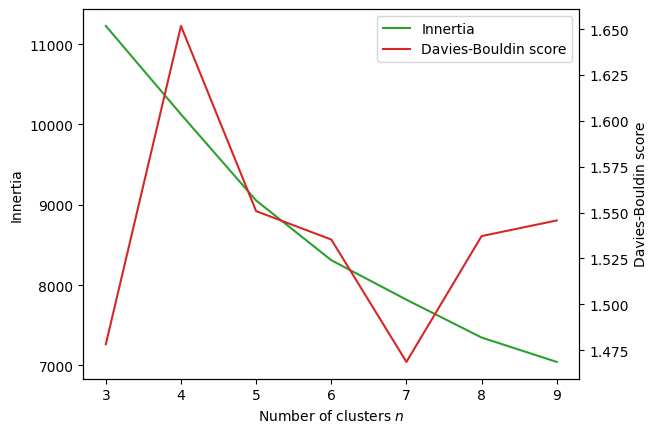

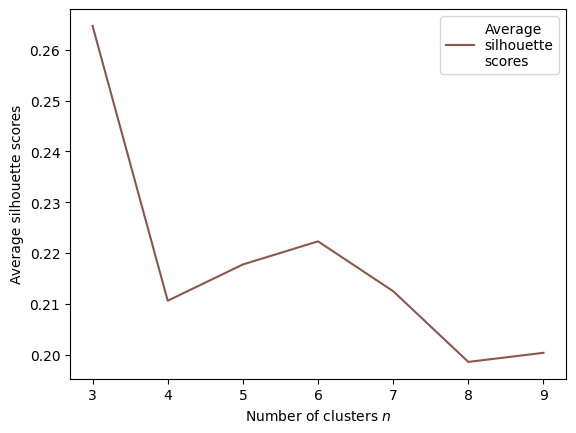

In [42]:
X_new = mall_df[[
    "Age",
    "Education", 
    "Income", 
    "IsParent", 
    "OnlineClient",
    "CustomerFrom",
    "Spent",
    "Children",
    "FamilySize",
]].values

scaler = StandardScaler()

X_scaled_new = scaler.fit_transform(X_new)
inertias, dbs, silhouette_scores = plot_cluster_search(X=X_scaled_new)

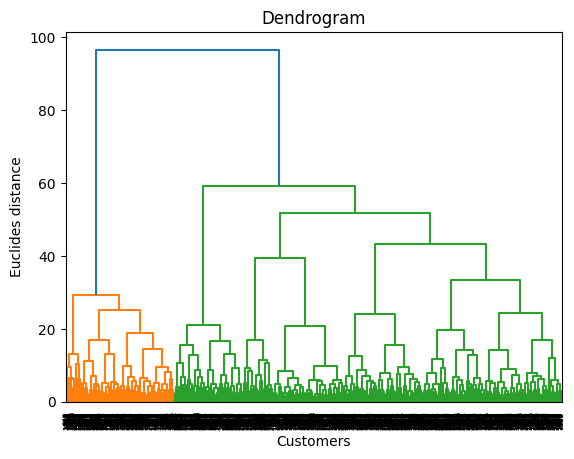

In [43]:
dendogram_new = sch.dendrogram(sch.linkage(X_scaled_new, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclides distance')
plt.show()

In [44]:
agg = AgglomerativeClustering(n_clusters=4)
agg_labels = agg.fit_predict(X_scaled_new)
ss_agg = silhouette_score(X_scaled_new, agg_labels)
db_agg = davies_bouldin_score(X_scaled_new, agg_labels)
ch_agg = calinski_harabasz_score(X_scaled_new, agg_labels)
print(f"Agglomerative — Silhouette: {ss_agg}, DB: {db_agg}, CH: {ch_agg}")

Agglomerative — Silhouette: 0.2070993944664397, DB: 1.658055483131515, CH: 501.2022035463391


K-Means — Silhouette: 0.21332527860393194, DB: 1.6142084305486275, CH: 537.7476371597114


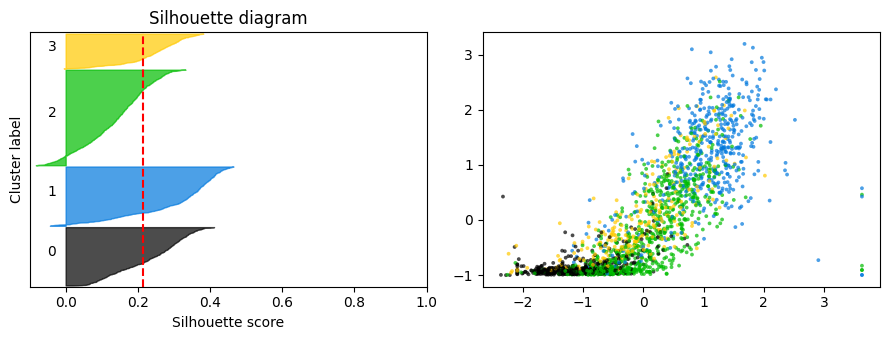

In [45]:
kmeans_labels_new = kmeans.fit_predict(X_scaled_new)
get_sillhouette_diagram(
    X=X_scaled_new,
    labels=kmeans_labels_new,
    n_clusters=4,
    show_scatter=True,
    first_feature_idx=2,
    sec_feature_idx=6
)

ss_km = silhouette_score(X_scaled_new, kmeans_labels_new)
db_km = davies_bouldin_score(X_scaled_new, kmeans_labels_new)
ch_km = calinski_harabasz_score(X_scaled_new, kmeans_labels_new)
print(f"K-Means — Silhouette: {ss_km}, DB: {db_km}, CH: {ch_km}")

In [46]:
nn = NearestNeighbors(n_neighbors=5)  # 5 neighbors (index 0 = self, so 4 true neighbors + self)
nbrs = nn.fit(X_scaled_new)

distances, indices = nbrs.kneighbors(X_scaled_new)
distances = distances[:, 4]
distances = np.sort(distances)

kl = KneeLocator(
    range(len(distances)),
    distances,
    curve='convex',
    direction='increasing'
)

suggested_eps_new = distances[kl.elbow]
print(f"Suggested epsilon in exercise 4: {suggested_eps_new}")


min_samples = range(3, 13)
eps = np.arange(0.2, suggested_eps_new, 0.01)
silhsc = {}
for ms in min_samples:
    silhsc[ms] = []
    for ep in eps:
        labels_db = DBSCAN(min_samples=ms, eps = ep).fit_predict(X_scaled_new)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        if n_clusters >= 2:
            silhsc[ms].append((n_clusters, ep, silhouette_score(X_scaled_new, labels_db)))
    if silhsc[ms]:
        silhsc[ms] = sorted(silhsc[ms], key=lambda x: x[-1])[-1]
    else:
        silhsc[ms] = (None, None, None) 
db_scan_params_search_df = pd.DataFrame(silhsc).T.reset_index().rename(columns={'index': 'NumPts', 0: 'Num of clusters', 1: 'epsilon',2: 'Silhouette index'})


print(db_scan_params_search_df)
best_params = db_scan_params_search_df.loc[db_scan_params_search_df["Silhouette index"].idxmax()]
print(f"\nBest params: \n{best_params}")

Suggested epsilon in exercise 4: 1.6921130965307603
   NumPts  Num of clusters  epsilon  Silhouette index
0       3              4.0     1.69          0.242882
1       4              4.0     1.69          0.241663
2       5              4.0     1.62          0.237756
3       6              4.0     1.60          0.220584
4       7              4.0     1.69          0.224591
5       8              3.0     1.58          0.253352
6       9              3.0     1.62          0.254133
7      10              3.0     1.66          0.253624
8      11              3.0     1.67          0.253676
9      12              3.0     1.69          0.253577

Best params: 
NumPts              9.000000
Num of clusters     3.000000
epsilon             1.620000
Silhouette index    0.254133
Name: 6, dtype: float64


Silhouette score: 0.254133036503678
davies bouldin scores: 1.9714217549255135
calinski hrabasz score: 424.41210723396017
Amount of points intepreted as noise: 92


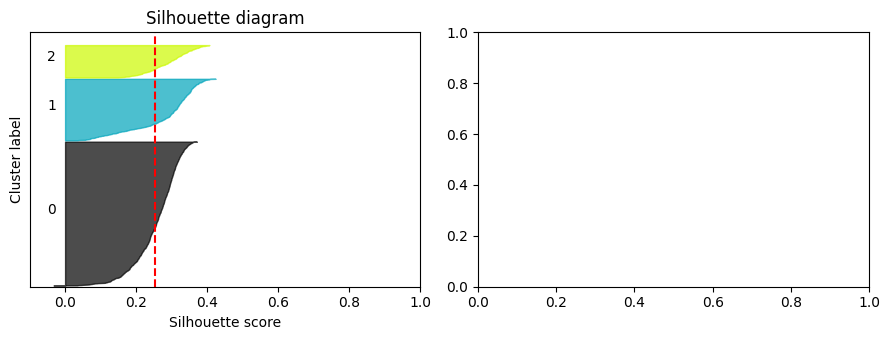

In [47]:
# Create DBSCAN with best found hyperparameters
samples = int(best_params["NumPts"])
eps = best_params["epsilon"].round(2)

labels_dbscan_new = DBSCAN(min_samples=samples, eps=eps).fit_predict(X_scaled_new)

ss = silhouette_score(X_scaled_new, labels_dbscan_new)
db = davies_bouldin_score(X_scaled_new, labels_dbscan_new)
ch = calinski_harabasz_score(X_scaled_new, labels_dbscan_new)

print(f"Silhouette score: {ss}")
print(f"davies bouldin scores: {db}")
print(f"calinski hrabasz score: {ch}")

noise_points = np.sum(labels_dbscan_new == -1)
print(f"Amount of points intepreted as noise: {noise_points}")

get_sillhouette_diagram(
    X=X_scaled_new,
    labels=labels_dbscan_new,
    n_clusters=len(set(labels_dbscan_new)) - (1 if -1 in labels_dbscan_new else 0),
    show_scatter=False,
)

In [48]:
# Agglomerative
print(f"Agglomerative — n clusters: {len(np.unique(agg_labels))}")
print(f"Points per cluster: {np.bincount(agg_labels)}")

# K-Means
print(f"K-Means — n clusters: {len(np.unique(kmeans_labels_new))}")
print(f"Points per cluster: {np.bincount(kmeans_labels_new)}")

# DBSCAN
n_clusters_db = len(set(labels_dbscan_new)) - (1 if -1 in labels_dbscan_new else 0)
print(f"DBSCAN — n clusters: {n_clusters_db}")
valid_mask = labels_dbscan_new != -1
print(f"Points per cluster: {np.bincount(labels_dbscan_new[valid_mask])}")

Agglomerative — n clusters: 4
Points per cluster: [886 408 275 443]
K-Means — n clusters: 4
Points per cluster: [474 481 775 282]
DBSCAN — n clusters: 3
Points per cluster: [1161  497  262]


Summary:

Adding feature engineering seems to improve clustering. I decided to keep 4 clusters based on computed metrics.

Silhouette diagrams seems to be much better fitted per cluster, especially in DBSCAN. (Almost no negative values, data seems well fitted to each cluster).

KMEANS metrics & Agglomerative Clustering seems to have similar scores in Silhouette score, davies bouldin score, calinski hrabasz score


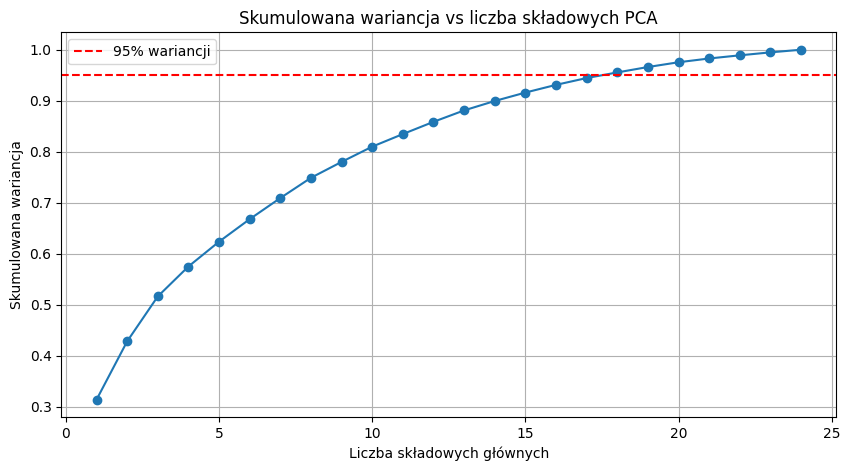

Liczba składowych dla ~70% wariancji: 7
Kształt macierzy po PCA: (2012, 7)
Skumulowana wariancja: 0.7091


In [49]:
from sklearn.decomposition import PCA
# # ZADANIE 5

# df = df.drop("Cluster", axis=1)
# df = df.drop("Cluster_HC", axis=1)

X_ex5 = df[df.columns].values
scaler = StandardScaler()

X_ex5_scaled = scaler.fit_transform(X_ex5)

cumulative_variances = []
for n in range(1, len(df.columns)):
    pca = PCA(n_components=n)
    pca.fit(X_ex5_scaled)
    cumulative_variances.append(np.sum(pca.explained_variance_ratio_))


plt.figure(figsize=(10, 5))
plt.plot(list(range(1, len(df.columns))), cumulative_variances, marker='o')
plt.xlabel('Liczba składowych głównych')
plt.ylabel('Skumulowana wariancja')
plt.title('Skumulowana wariancja vs liczba składowych PCA')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% wariancji')
plt.legend()
plt.grid(True)
plt.show()

n_components_70_var = next(i + 1 for i, v in enumerate(cumulative_variances) if v >= 0.70)
print(f"Liczba składowych dla ~70% wariancji: {n_components_70_var}")

pca_final = PCA(n_components=n_components_70_var)
X_pca = pca_final.fit_transform(X_ex5_scaled)
print(f"Kształt macierzy po PCA: {X_pca.shape}")
print(f"Skumulowana wariancja: {np.sum(pca_final.explained_variance_ratio_):.4f}")

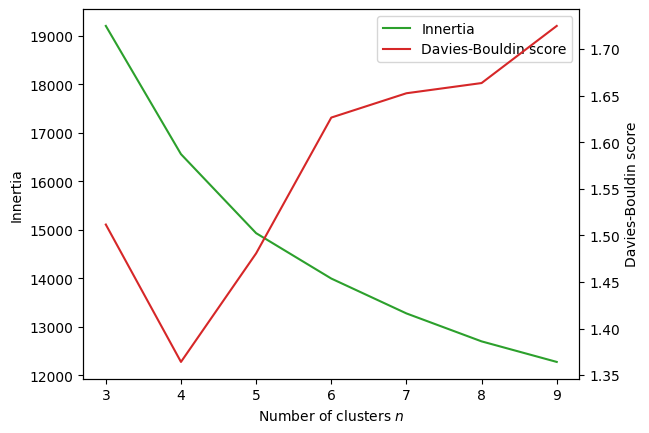

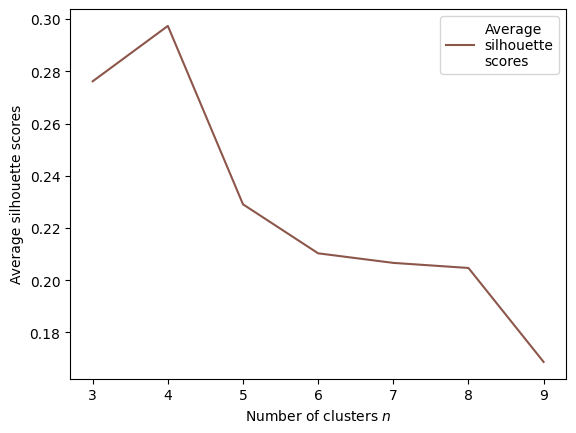

In [50]:
# Plot suggested clusters for clustering algorithms using matrix from PCA
inertias, dbs, silhouette_scores = plot_cluster_search(X=X_pca)

# Suggested 3-4 clusters using PCA data

K-Means — n clusters: 3
Points per cluster: [557 922 533]
K-Means — Silhouette: 0.2767, DB: 1.5095, CH: 861.3345


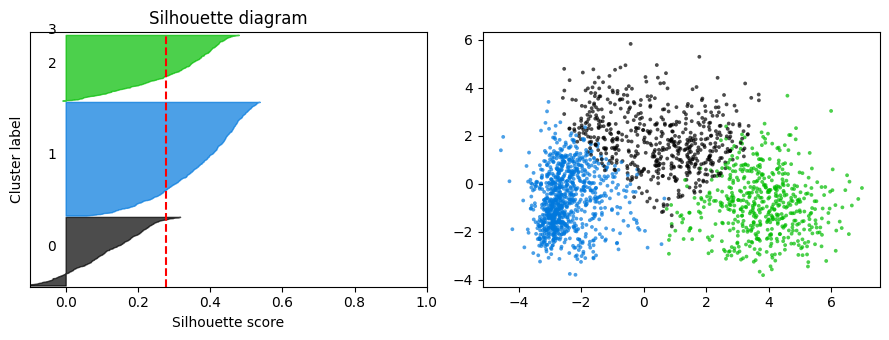

In [51]:
# Based on above metrics i decided to choose 3 clusters. The silhouette score is highest at n=3 (~ 0.265) 
# K-MEANS Clustering
kmeans_pca = KMeans(n_clusters=3, random_state=42)
kmeans_labels_pca = kmeans_pca.fit_predict(X_pca)

print(f"K-Means — n clusters: {len(np.unique(kmeans_labels_pca))}")
print(f"Points per cluster: {np.bincount(kmeans_labels_pca)}")

ss_km_pca = silhouette_score(X_pca, kmeans_labels_pca)
db_km_pca = davies_bouldin_score(X_pca, kmeans_labels_pca)
ch_km_pca = calinski_harabasz_score(X_pca, kmeans_labels_pca)
print(f"K-Means — Silhouette: {ss_km_pca:.4f}, DB: {db_km_pca:.4f}, CH: {ch_km_pca:.4f}")

get_sillhouette_diagram(
    X=X_pca,
    labels=kmeans_labels_pca,
    n_clusters=4,
    show_scatter=True,
    first_feature_idx=0,
    sec_feature_idx=1
)

In [52]:
# Agglomerative Clustering
hc_pca = AgglomerativeClustering(n_clusters=3)
hc_labels_pca = hc_pca.fit_predict(X_scaled)

print(f"HC — n clusters: {len(np.unique(hc_labels_pca))}")
print(f"Points per cluster: {np.bincount(hc_labels_pca)}")

ss_hc_pca = silhouette_score(X_pca, hc_labels_pca)
db_hc_pca = davies_bouldin_score(X_pca, hc_labels_pca)
ch_hc_pca = calinski_harabasz_score(X_pca, hc_labels_pca)
print(f"HC — Silhouette: {ss_hc_pca:.4f}, DB: {db_hc_pca:.4f}, CH: {ch_hc_pca:.4f}")

HC — n clusters: 3
Points per cluster: [547 577 888]
HC — Silhouette: 0.2329, DB: 1.8154, CH: 698.3356


In [ ]:
# DBSCAN Clustering

nn_pca = NearestNeighbors(n_neighbors=5)
nbrs_pca = nn_pca.fit(X_pca)
distances_pca, _ = nbrs_pca.kneighbors(X_pca)
distances_pca = np.sort(distances_pca[:, 4])

kl_pca = KneeLocator(range(len(distances_pca)), distances_pca, curve='convex', direction='increasing')
suggested_eps_pca = distances_pca[kl_pca.elbow]
print(f"Suggested epsilon (PCA): {suggested_eps_pca:.4f}")

n_features_pca = X_pca.shape[1]
min_samples = range(n_features_pca + 1, n_features_pca + 11) 
eps = np.arange(0.2, suggested_eps_pca, 0.01)
silhsc_pca = {}
for ms in min_samples:
    silhsc_pca[ms] = []
    for ep in eps:
        labels_db_pca = DBSCAN(min_samples=ms, eps = ep).fit_predict(X_pca)
        n_clusters_pca = len(set(labels_db_pca)) - (1 if -1 in labels_db_pca else 0)
        if n_clusters_pca >= 2:
            silhsc_pca[ms].append((n_clusters_pca, ep, silhouette_score(X_pca, labels_db_pca)))
    if silhsc_pca[ms]:
        silhsc_pca[ms] = sorted(silhsc_pca[ms], key=lambda x: x[-1])[-1]
    else:
        silhsc_pca[ms] = (None, None, None) 
db_scan_params_search_df_pca = pd.DataFrame(silhsc_pca).T.reset_index().rename(columns={'index': 'NumPts', 0: 'Num of clusters', 1: 'epsilon',2: 'Silhouette index'})

db_scan_params_pca = db_scan_params_search_df_pca.loc[db_scan_params_search_df_pca["Silhouette index"].idxmax()]
print(f"\nBest DBSCAN params:\n{db_scan_params_pca}")

Suggested epsilon (PCA): 2.8385

Best DBSCAN params:
NumPts              16.000000
Num of clusters      3.000000
epsilon              2.000000
Silhouette index     0.163052
Name: 8, dtype: float64


In [ ]:
labels_dbscan_pca = DBSCAN(
    min_samples=int(db_scan_params_pca["NumPts"]),
    eps=db_scan_params_pca["epsilon"].round(2)
).fit_predict(X_pca)

n_clusters_db_pca = len(set(labels_dbscan_pca)) - (1 if -1 in labels_dbscan_pca else 0)
noise_pca = np.sum(labels_dbscan_pca == -1)
print(f"DBSCAN — n clusters: {n_clusters_db_pca}")
print(f"Points per cluster: {np.bincount(labels_dbscan_pca[labels_dbscan_pca != -1])}")
print(f"Noise points: {noise_pca}")

ss_dbscan_pca = silhouette_score(X_pca, labels_dbscan_pca)
db_dbscan_pca = davies_bouldin_score(X_pca, labels_dbscan_pca)
ch_dbscan_pca = calinski_harabasz_score(X_pca, labels_dbscan_pca)
print(f"DBSCAN — Silhouette: {ss_dbscan_pca:.4f}, DB: {db_dbscan_pca:.4f}, CH: {ch_dbscan_pca:.4f}")

DBSCAN — n_clusters: 3
Points per cluster: [1157  342  164]
Noise points: 349
DBSCAN — Silhouette: 0.1631, DB: 1.9338, CH: 378.8035
